In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import randint,uniform
from sklearn.model_selection import GroupShuffleSplit,StratifiedGroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score,recall_score,f1_score
import seaborn as sns


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format",lambda x: f"{x:.3f}")
sns.set_style("whitegrid")
sns.set_theme(style="darkgrid")
RANDOM_STATE = 42
TARGET = "target"
df = pd.read_csv("./Dataset/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.000,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.100,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.600,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.000,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.900,1,3,2,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [9]:
df["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [8]:
numerical_features = [
    "age","trestbps","chol","thalach","oldpeak","ca"
]
categorical_features = [
    "sex","cp","fbs","restecg","exang","slope","thal","target"]

In [3]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
# duplicates rows
duplicated_mask = df.duplicated()
num_duplicates = duplicated_mask.sum()
num_duplicates

np.int64(723)

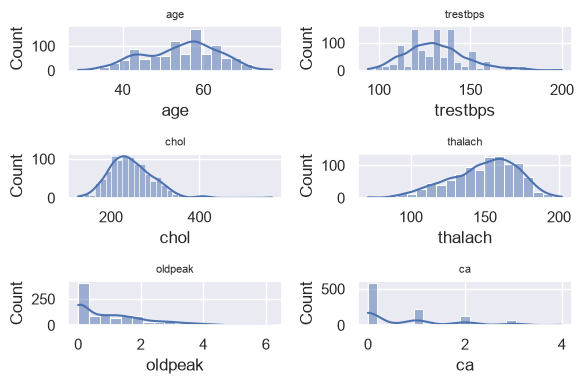

In [11]:
# histplot
fig,axes = plt.subplots(3,2,figsize=(6,4))
axes = axes.flatten()
for i,col in enumerate(numerical_features):
    sns.histplot(df[col],kde=True,ax=axes[i])
    axes[i].set_title(col,fontsize=8)

plt.tight_layout()
plt.show()

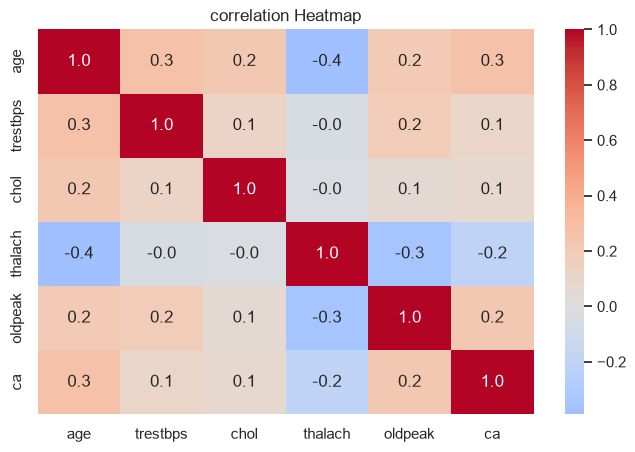

In [12]:
plt.figure(figsize=(8,5))
sns.heatmap(
    df[numerical_features].corr(),cmap="coolwarm",annot=True,fmt=".1f",center=0
)
plt.title("correlation Heatmap")
plt.show()

In [13]:
# Data Preprocessing
X= df.drop(columns=[TARGET])
y =df[TARGET]
#creating row signature.
row_signature = pd.util.hash_pandas_object(X,index=False)

In [14]:
gss = GroupShuffleSplit(
    n_splits=1,test_size=0.15,random_state=RANDOM_STATE
)
train_idx,test_idx = next(
    gss.split(X,y,groups=row_signature)
)
X_train,X_test = X.iloc[train_idx],X.iloc[test_idx]
y_train,y_test = y.iloc[train_idx],y.iloc[test_idx]

In [15]:
base_pipe = Pipeline(
    steps=[
        ("scaler",StandardScaler()),
        ("model",LogisticRegression())
    ]
)
base_pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','sex','cp',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [16]:
def evaluate_classifier(model,X_train,y_train,X_test,y_test,model_name):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train,y_train_pred) *100
    test_acc = accuracy_score(y_test,y_test_pred) * 100
    print(f"{model_name} - Train Acc:{train_acc:.2f}%")
    print(f"{model_name} - Test acc:{test_acc:.2f}%")
    print("-" * 40)
    print("Training classification report")
    print(classification_report(y_train,y_train_pred))
    print("-" * 40)
    print("Test classification report")
    print(classification_report(y_test,y_test_pred))


In [17]:
evaluate_classifier(
    base_pipe,X_train,y_train,X_test,y_test,model_name="Logistic Regression - Base Model"
)

Logistic Regression - Base Model - Train Acc:84.23%
Logistic Regression - Base Model - Test acc:83.33%
----------------------------------------
Training classification report
              precision    recall  f1-score   support

           0       0.88      0.79      0.83       430
           1       0.81      0.89      0.85       439

    accuracy                           0.84       869
   macro avg       0.85      0.84      0.84       869
weighted avg       0.85      0.84      0.84       869

----------------------------------------
Test classification report
              precision    recall  f1-score   support

           0       0.89      0.71      0.79        69
           1       0.80      0.93      0.86        87

    accuracy                           0.83       156
   macro avg       0.85      0.82      0.83       156
weighted avg       0.84      0.83      0.83       156



In [18]:
models = {
    "Logistic Regression":LogisticRegression(random_state=RANDOM_STATE),
    "Support Vector Machine":SVC(random_state=RANDOM_STATE),
    "Random Forest":RandomForestClassifier(random_state=RANDOM_STATE),
    "XGBoost":XGBClassifier()
}

In [19]:
groups = pd.util.hash_pandas_object(X_train,index=False)
k=5
cv = StratifiedGroupKFold(n_splits=k,shuffle=True,random_state=RANDOM_STATE)

In [21]:
for name, model in models.items():
    recall_scores=[]
    f1_scores=[]
    for tr_idx,te_idx in cv.split(X_train,y_train,groups=groups):
        X_tr,X_te = X_train.iloc[tr_idx],X_train.iloc[te_idx]
        y_tr,y_te = y_train.iloc[tr_idx],y_train.iloc[te_idx]
        pipeline = Pipeline(
            steps=[
                ("scaler",StandardScaler()),
                ("model",model)
            ]
        )
        pipeline.fit(X_tr,y_tr)
        pred = pipeline.predict(X_te)
        recall_scores.append(round(recall_score(y_te,pred),2))
        f1_scores.append(round(f1_score(y_te,pred),2))
    print("Model Name:", name)
    print("Recall values",recall_scores)
    print("F1 scores",f1_scores)



Model Name: Logistic Regression
Recall values [0.9, 0.75, 0.93, 0.89, 0.82]
F1 scores [0.87, 0.75, 0.91, 0.82, 0.75]
Model Name: Support Vector Machine
Recall values [0.79, 0.72, 0.82, 0.96, 0.72]
F1 scores [0.76, 0.76, 0.84, 0.83, 0.69]
Model Name: Random Forest
Recall values [0.93, 0.82, 0.9, 0.92, 0.82]
F1 scores [0.88, 0.81, 0.87, 0.87, 0.75]
Model Name: XGBoost
Recall values [0.82, 0.72, 0.9, 0.97, 0.82]
F1 scores [0.79, 0.78, 0.86, 0.87, 0.72]


In [22]:
# hyper parameter tuning.
rfc_pipeline= Pipeline(
    steps=[
        ("scaler",StandardScaler()),
        ("model",RandomForestClassifier(random_state=RANDOM_STATE,n_jobs=-1))
    ]
)
# parameter distributions
param_dist = {
    "model__n_estimators": randint(400, 1200),
    "model__max_depth": [3, 4, 5, 6],
    "model__min_samples_split": randint(10, 40),
    "model__min_samples_leaf": randint(4, 20),
    "model__max_features": [0.25, 0.35, 0.5, "sqrt"],
    "model__bootstrap": [True],
    "model__max_samples": uniform(0.6, 0.35),
    "model__ccp_alpha": uniform(0.0, 0.02),
}

In [23]:
random_search = RandomizedSearchCV(
    estimator=rfc_pipeline,
    param_distributions=param_dist,
    n_iter=60,
    scoring ="f1_macro",
    cv=cv,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

In [24]:
random_search.fit(X_train,y_train,groups=groups)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__bootstrap': [True], 'model__ccp_alpha': <scipy.stats....0021279DB9BD0>, 'model__max_depth': [3, 4, ...], 'model__max_features': [0.25, 0.35, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",60
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a 

In [25]:
print("Hyperparameter Tuning result:")
print("Best params:", random_search.best_params_)
print("Best score:", random_search.best_score_)

Hyperparameter Tuning result:
Best params: {'model__bootstrap': True, 'model__ccp_alpha': np.float64(0.00176985004103839), 'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__max_samples': np.float64(0.6158295511186883), 'model__min_samples_leaf': 11, 'model__min_samples_split': 30, 'model__n_estimators': 1119}
Best score: 0.8484741292730688


In [26]:
rfc_best = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            n_estimators=random_search.best_params_["model__n_estimators"],
            max_depth=random_search.best_params_["model__max_depth"],
            min_samples_split=random_search.best_params_["model__min_samples_split"],
            min_samples_leaf=random_search.best_params_["model__min_samples_leaf"],
            max_features=random_search.best_params_["model__max_features"],
            bootstrap=random_search.best_params_["model__bootstrap"],
        ))
    ]
)

In [27]:
rfc_best.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','sex','cp',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [28]:
evaluate_classifier(
    rfc_best,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="Random Forest - Best Model"
)

Random Forest - Best Model - Train Acc:91.25%
Random Forest - Best Model - Test acc:81.41%
----------------------------------------
Training classification report
              precision    recall  f1-score   support

           0       0.94      0.88      0.91       430
           1       0.89      0.94      0.92       439

    accuracy                           0.91       869
   macro avg       0.91      0.91      0.91       869
weighted avg       0.91      0.91      0.91       869

----------------------------------------
Test classification report
              precision    recall  f1-score   support

           0       0.84      0.71      0.77        69
           1       0.80      0.90      0.84        87

    accuracy                           0.81       156
   macro avg       0.82      0.80      0.81       156
weighted avg       0.82      0.81      0.81       156



In [29]:
def predict_heart_disease(input_features):

    # create DataFrame with correct column order
    input_df = pd.DataFrame(
        [input_features],
        columns=X_train.columns
    )

    # class prediction
    prediction = rfc_best.predict(input_df)[0]

    # probability prediction (positive class)
    probability = rfc_best.predict_proba(input_df)[0][1]

    # output
    print(f"Predicted class: {prediction}")
    print(f"Heart disease risk probability: {probability:.2%}")

    if prediction == 1:
        print("Diagnosis: High risk of heart disease 🔴")
    else:
        print("Diagnosis: Low risk of heart disease 🟢")

    return prediction, probability

In [30]:
test_1 = X_test.loc[24].tolist()
predict_heart_disease(test_1)

Predicted class: 1
Heart disease risk probability: 96.53%
Diagnosis: High risk of heart disease 🔴


(np.int64(1), np.float64(0.9653486473533656))